# 11 — Bump Chart
**When to use:** Show how rankings change over time.
Example: which channel ranked #1 in CVR each week? Did paid improve or drop?

A bump chart uses rank on the y-axis (1 = best at top) and time on the x-axis.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])
df['week'] = df['date'].dt.isocalendar().week.astype(int)

PALETTE = {
    'direct':  '#4361ee',
    'email':   '#06d6a0',
    'organic': '#ff9f1c',
    'paid':    '#f72585',
    'social':  '#7209b7',
}
print(df['week'].unique())

[ 1  2  3  4  5  6  7  8  9 10 11 12 13]


## 1. Weekly CVR ranking by channel

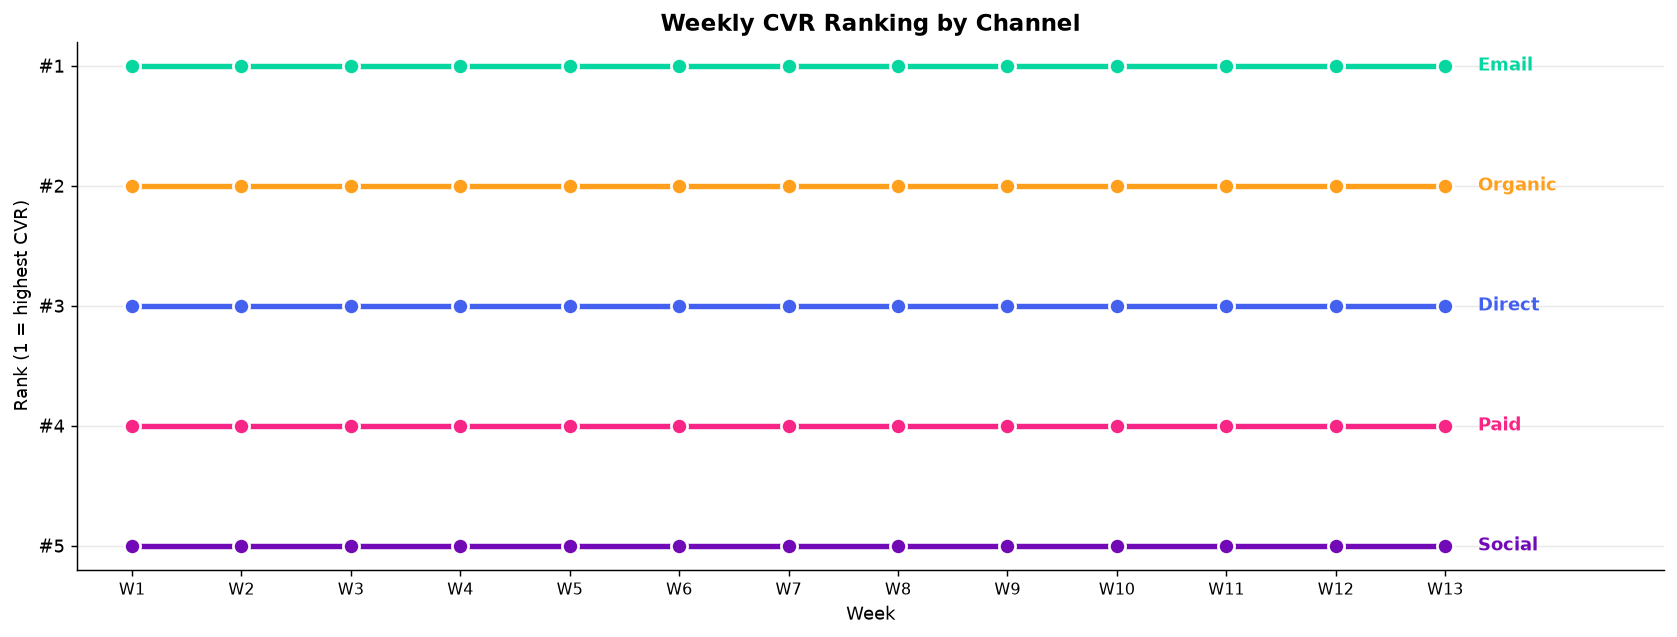

In [2]:
# Compute weekly CVR per channel
weekly = df.groupby(['week', 'channel']).apply(
    lambda g: g['activacion_tarjeta'].sum() / g['visita_landing'].sum() * 100
).reset_index(name='cvr')

# Rank channels within each week (rank 1 = highest CVR)
weekly['rank'] = weekly.groupby('week')['cvr'].rank(ascending=False).astype(int)

weeks    = sorted(weekly['week'].unique())
channels = sorted(weekly['channel'].unique())
n_channels = len(channels)

fig, ax = plt.subplots(figsize=(13, 5), dpi=130)

for ch in channels:
    ch_df = weekly[weekly['channel'] == ch].sort_values('week')
    color = PALETTE[ch]

    # Main line — thick and smooth
    ax.plot(ch_df['week'], ch_df['rank'],
            color=color, linewidth=3, solid_capstyle='round')

    # Dots at each week
    ax.scatter(ch_df['week'], ch_df['rank'],
               color=color, s=80, zorder=5, edgecolors='white', linewidth=1.5)

    # Label at the end of the line
    last = ch_df[ch_df['week'] == ch_df['week'].max()].iloc[0]
    ax.text(last['week'] + 0.3, last['rank'],
            ch.capitalize(), va='center', fontsize=10,
            color=color, fontweight='bold')

# Invert y-axis so rank 1 is at the top
ax.invert_yaxis()
ax.set_yticks(range(1, n_channels + 1))
ax.set_yticklabels([f'#{i}' for i in range(1, n_channels + 1)], fontsize=10)
ax.set_xticks(weeks)
ax.set_xticklabels([f'W{w}' for w in weeks], fontsize=9)

ax.set_title('Weekly CVR Ranking by Channel', fontsize=13, fontweight='bold')
ax.set_xlabel('Week')
ax.set_ylabel('Rank (1 = highest CVR)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlim(weeks[0] - 0.5, weeks[-1] + 2)  # extra space for labels

plt.tight_layout()
plt.savefig('data/11_bump_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Monthly volume ranking

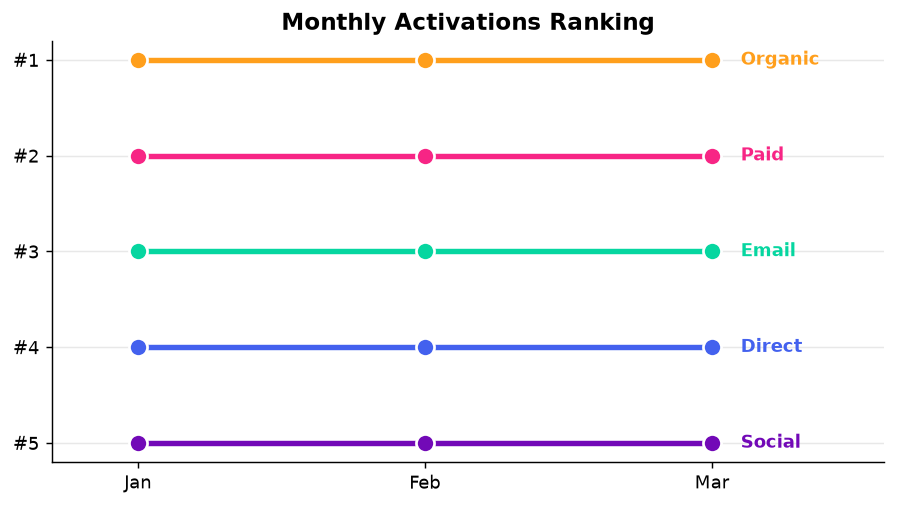

In [3]:
df['month'] = df['date'].dt.month

monthly = df.groupby(['month', 'channel'])['activacion_tarjeta'].sum().reset_index()
monthly['rank'] = monthly.groupby('month')['activacion_tarjeta'].rank(ascending=False).astype(int)
months = sorted(monthly['month'].unique())
month_names = ['Jan', 'Feb', 'Mar']

fig, ax = plt.subplots(figsize=(7, 4), dpi=130)

for ch in channels:
    ch_df = monthly[monthly['channel'] == ch].sort_values('month')
    color = PALETTE[ch]

    ax.plot(ch_df['month'], ch_df['rank'], color=color, linewidth=3)
    ax.scatter(ch_df['month'], ch_df['rank'],
               color=color, s=100, zorder=5, edgecolors='white', linewidth=1.5)

    last = ch_df[ch_df['month'] == ch_df['month'].max()].iloc[0]
    ax.text(last['month'] + 0.08, last['rank'],
            f' {ch.capitalize()}', va='center', fontsize=10, color=color, fontweight='bold')

ax.invert_yaxis()
ax.set_yticks(range(1, n_channels + 1))
ax.set_yticklabels([f'#{i}' for i in range(1, n_channels + 1)])
ax.set_xticks(months)
ax.set_xticklabels(month_names)
ax.set_xlim(0.7, 3.6)
ax.set_title('Monthly Activations Ranking', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Summary
| Concept | Key point |
|---|---|
| **Y-axis** | Rank (1 = best), inverted so #1 is at the top |
| **X-axis** | Time (week, month) |
| **Labels** | At the end of each line, colored to match |
| **Best for** | Showing channel/campaign ranking changes over time |

**Next:** `12_cohort_heatmap.ipynb`